AI Usage Disclosure

AI tools were used during the development of this assignment to explain concepts, provide coding guidance, suggest code examples, help interpret results, and assist with debugging.
All AI-generated content used in this notebook is explicitly marked with beginning and ending comments. The code and explanations were reviewed and tested by the student, who is responsible for understanding and verifying the submitted work.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Environment is ready!")

Environment is ready!


In [2]:
ratings_df = pd.read_csv("../data/ratings.csv")
movies_df = pd.read_csv("../data/movies.csv")

In [3]:
print("Ratings shape:", ratings_df.shape)
print("Movies shape:", movies_df.shape)

display(ratings_df.head())
display(movies_df.head())

Ratings shape: (100836, 4)
Movies shape: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
num_users = ratings_df["userId"].nunique()
num_movies = ratings_df["movieId"].nunique()
num_ratings = len(ratings_df)

sparsity = 1 - (num_ratings / (num_users * num_movies))

print("Number of unique users:", num_users)
print("Number of unique movies rated:", num_movies)
print("Number of ratings:", num_ratings)
print("Sparsity:", sparsity)
print("Sparsity percentage:", sparsity * 100, "%")

Number of unique users: 610
Number of unique movies rated: 9724
Number of ratings: 100836
Sparsity: 0.9830003169443864
Sparsity percentage: 98.30003169443864 %


In [5]:
user_item_matrix = ratings_df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

print("Matrix shape:", user_item_matrix.shape)
display(user_item_matrix.iloc[:5, :10])

Matrix shape: (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10
userId,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


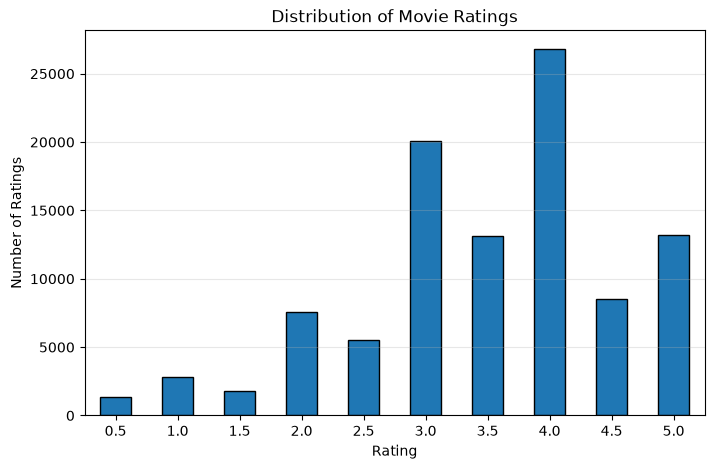

In [6]:
rating_counts = ratings_df["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
rating_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

Observation: The rating distribution shows that 4.0 is the most frequent rating, followed by 3.0. Ratings between 3.0 and 5.0 are generally more common than low ratings. This suggests that users tend to give relatively positive ratings in this dataset, while very low ratings are less frequent
"AI"

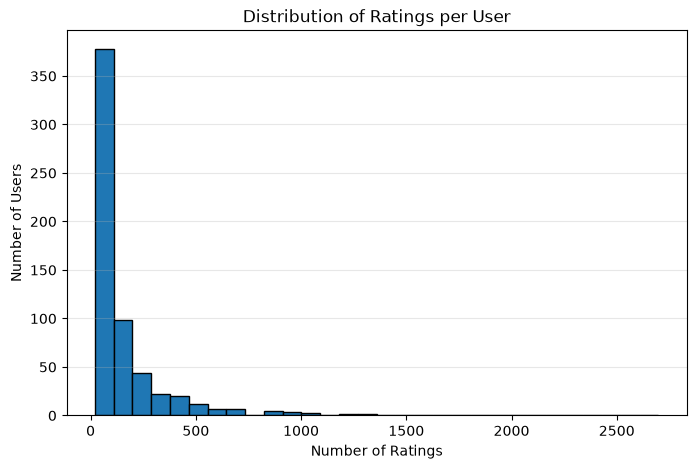

In [7]:
ratings_per_user = ratings_df.groupby("userId")["rating"].count()

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=30, edgecolor="black")

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.grid(axis="y", alpha=0.3)
plt.show()

Observation: The distribution of ratings per user is highly right-skewed. Most users have rated a relatively small number of movies, while a small number of users have rated hundreds or even thousands of movies. This indicates that user activity is not evenly distributed across the dataset."AI"

In [8]:
ratings_per_user.describe()

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64

observation: The dataset contains 610 users, with an average of approximately 165 ratings per user and a median of 70.5. Since the mean is much higher than the median and the maximum number of ratings is 2,698, the distribution is highly right-skewed. Most users have rated relatively few movies, while a small number of users are much more active. "AI"

In [10]:
def get_co_rated(matrix, a, b, axis):
    if axis == 0:
        ratings_a = matrix.loc[a]
        ratings_b = matrix.loc[b]
    elif axis == 1:
        ratings_a = matrix[a]
        ratings_b = matrix[b]
    else:
        raise ValueError("axis must be 0 or 1")

    co_rated = ratings_a.notna() & ratings_b.notna()
    return (
        ratings_a[co_rated].to_numpy(),
        ratings_b[co_rated].to_numpy()
    )

In [ ]:
test_matrix = pd.DataFrame(
    {
        10: [5.0, 4.0],
        20: [np.nan, 2.0],
        30: [3.0, np.nan]
    },
    index=[1, 2]
)

user_a, user_b = get_co_rated(test_matrix, 1, 2, axis=0)

print("User 1 ratings:", user_a)
print("User 2 ratings:", user_b)

User 1 ratings: [5.]
User 2 ratings: [4.]


In [ ]:
def euclidean_similarity(matrix, a, b, axis):
    ratings_a, ratings_b = get_co_rated(matrix, a, b, axis)
    if len(ratings_a) == 0:
        return None

    distance = np.sqrt(np.sum((ratings_a - ratings_b) ** 2))
    similarity = 1 / (1 + distance)
    return similarity

In [13]:
test_a = np.array([5, 4, 5, 3])
test_b = np.array([3, 2, 3, 1])

distance = np.sqrt(np.sum((test_a - test_b) ** 2))
similarity = 1 / (1 + distance)

print("Euclidean Distance:", distance)
print("Euclidean Similarity:", similarity)

Euclidean Distance: 4.0
Euclidean Similarity: 0.2


In [ ]:
def cosine_similarity(matrix, a, b, axis):
    ratings_a, ratings_b = get_co_rated(matrix, a, b, axis)
    if len(ratings_a) == 0:
        return None

    norm_a = np.sqrt(np.sum(ratings_a ** 2))
    norm_b = np.sqrt(np.sum(ratings_b ** 2))

    if norm_a == 0 or norm_b == 0:
        return None

    similarity = np.sum(ratings_a * ratings_b) / (norm_a * norm_b)
    return similarity

In [15]:
test_cosine_matrix = pd.DataFrame(
    [[5, 4, 5, 3],
     [3, 2, 3, 1]],
    index=[1, 2],
    columns=[10, 20, 30, 40]
)
result = cosine_similarity(test_cosine_matrix, 1, 2, axis=0)
print("Cosine Similarity:", result)

Cosine Similarity: 0.9871639953033075


In [16]:
def pearson_similarity(matrix, a, b, axis):
    ratings_a, ratings_b = get_co_rated(matrix, a, b, axis)
    if len(ratings_a) < 2:
        return None

    mean_a = np.mean(ratings_a)
    mean_b = np.mean(ratings_b)
    centered_a = ratings_a - mean_a
    centered_b = ratings_b - mean_b
    numerator = np.sum(centered_a * centered_b)
    denominator = np.sqrt(np.sum(centered_a ** 2)) * np.sqrt(
        np.sum(centered_b ** 2)
    )

    if denominator == 0:
        return None

    return numerator / denominator

In [17]:
result = pearson_similarity(test_cosine_matrix, 1, 2, axis=0)
print("Pearson Correlation:", result)

Pearson Correlation: 1.0


In [18]:
# Case 1: Two users with no commonly rated movies
no_overlap_matrix = pd.DataFrame(
    {
        10: [5.0, np.nan],
        20: [np.nan, 3.0]
    },
    index=[1, 2]
)

print("No overlap:")
print("Euclidean:", euclidean_similarity(no_overlap_matrix, 1, 2, axis=0))
print("Cosine:", cosine_similarity(no_overlap_matrix, 1, 2, axis=0))
print("Pearson:", pearson_similarity(no_overlap_matrix, 1, 2, axis=0))


# Case 2: Two users with only one commonly rated movie
one_overlap_matrix = pd.DataFrame(
    {
        10: [5.0, 3.0],
        20: [4.0, np.nan]
    },
    index=[1, 2]
)

print("\nOne common rating:")
print("Euclidean:", euclidean_similarity(one_overlap_matrix, 1, 2, axis=0))
print("Cosine:", cosine_similarity(one_overlap_matrix, 1, 2, axis=0))
print("Pearson:", pearson_similarity(one_overlap_matrix, 1, 2, axis=0))

No overlap:
Euclidean: None
Cosine: None
Pearson: None

One common rating:
Euclidean: 0.3333333333333333
Cosine: 1.0
Pearson: None


The above test is AI Generated